# Bipartite Respondent-Statement Network

Family 2: a **bipartite network** with two node types — respondents and statements —
and an edge whenever a respondent agrees with a statement. Projecting this bipartite
graph gives two derived networks for free:

- **statement-statement** (co-endorsement): which statements tend to be agreed with
  by the same people — a data-driven check on the survey's T/E/S/V topic labels;
- **respondent-respondent** (co-agreement): an alternative to the direct
  correlation-based network in `Respondent_Similarity_Network.ipynb`, built from shared
  *agreement* rather than overall answer-pattern correlation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from networkx.algorithms import bipartite
from networkx.algorithms.community import louvain_communities
from sklearn.metrics import adjusted_rand_score

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

## 1. Load and encode the data

In [2]:
df = pd.read_csv("Survey_Results_UC.csv", encoding="utf-8-sig")
df = df.rename(columns={"id. Response ID": "respondent_id"})
df = df.set_index("respondent_id")

category_map = {col: col[0] for col in df.columns}
category_names = {"T": "Technology", "E": "Education", "S": "Ethics/Society", "V": "Environment"}
statement_cols = list(df.columns)

likert_map = {"Strongly Disagree": -2, "Disagree": -1, "Neutral": 0, "Agree": 1, "Strongly Agree": 2}
df_num = df.replace({"": np.nan, "No Comments": np.nan}).replace(likert_map).apply(pd.to_numeric)

print(f"Respondents: {df_num.shape[0]}, Statements: {df_num.shape[1]}")

Respondents: 96, Statements: 60


## 2. Build the bipartite graph

An edge connects a respondent to a statement whenever they **agree** with it (score
>= 1, i.e. Agree or Strongly Agree) — a simple, standard binarization for turning an
ordinal endorsement matrix into a bipartite agreement network. Respondents/statements
that never/always agree still appear as nodes, just with degree 0 in this graph.

In [3]:
AGREE_THRESHOLD = 1  # >= "Agree"

agree = (df_num >= AGREE_THRESHOLD)

B = nx.Graph()
B.add_nodes_from(df_num.index, bipartite="respondent")
B.add_nodes_from(statement_cols, bipartite="statement")
for resp_id, row in agree.iterrows():
    for stmt in row.index[row]:
        B.add_edge(resp_id, stmt)

resp_nodes = {n for n, d in B.nodes(data=True) if d["bipartite"] == "respondent"}
stmt_nodes = {n for n, d in B.nodes(data=True) if d["bipartite"] == "statement"}
print(f"Bipartite graph: {len(resp_nodes)} respondents, {len(stmt_nodes)} statements, {B.number_of_edges()} agree-edges")
print(f"Bipartite density: {bipartite.density(B, resp_nodes):.3f}")
print(bipartite.is_bipartite(B))

Bipartite graph: 96 respondents, 60 statements, 4165 agree-edges
Bipartite density: 0.723
True


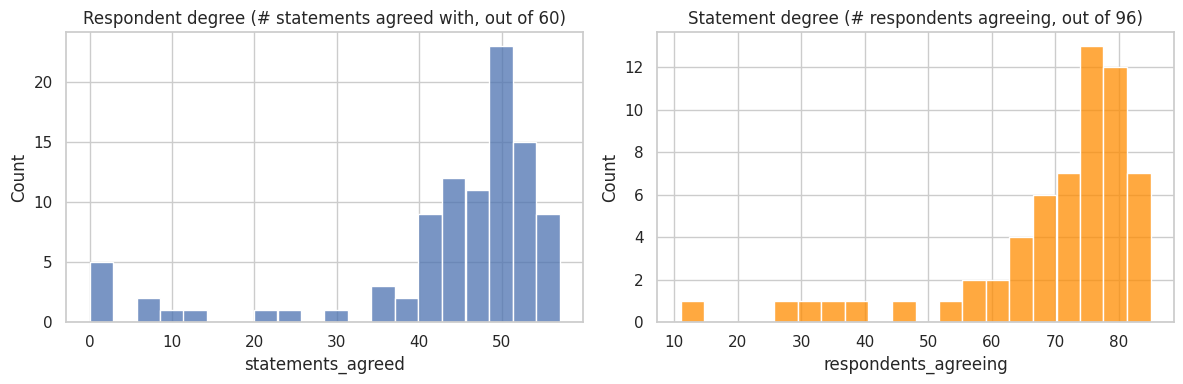

Statements with the broadest agreement:


E15. Continuous learning and skill development are essential throughout one's career.                              85
S11. People should be free to express differing opinions as long as they do not promote harm or discrimination.    84
V13. Companies should be held accountable for the environmental impacts of their activities.                       83
E11. University curricula should be updated more frequently to match emerging technologies.                        82
T14. Social media algorithms contribute to opinion polarization.                                                   82
Name: respondents_agreeing, dtype: int64


Statements with the least agreement:


E03. Class attendance should be compulsory for all courses.                                     11
E02. Traditional written examinations accurately measure a student's knowledge.                 28
E13. Universities should invest more resources in research than in expanding infrastructure.    32
T08. AI-assisted diagnosis should become routine in healthcare.                                 34
T09. Autonomous vehicles will ultimately make transportation safer.                             38
Name: respondents_agreeing, dtype: int64

In [4]:
resp_degree = pd.Series({n: B.degree(n) for n in resp_nodes}, name="statements_agreed")
stmt_degree = pd.Series({n: B.degree(n) for n in stmt_nodes}, name="respondents_agreeing")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(resp_degree, bins=20, ax=axes[0])
axes[0].set_title("Respondent degree (# statements agreed with, out of 60)")
sns.histplot(stmt_degree, bins=20, ax=axes[1], color="darkorange")
axes[1].set_title("Statement degree (# respondents agreeing, out of 96)")
plt.tight_layout()
plt.show()

print("Statements with the broadest agreement:")
display(stmt_degree.sort_values(ascending=False).head(5))
print("\nStatements with the least agreement:")
display(stmt_degree.sort_values(ascending=True).head(5))

## 3. Projection A — statement-statement (co-endorsement) network

Standard bipartite projection: two statements are connected if agreed with by the same
respondents, weighted by the *overlap* in who agreed (Jaccard-like weight via
`overlap_weighted_projected_graph`, which is robust to statements having very
different overall popularity).

In [5]:
G_stmt = bipartite.overlap_weighted_projected_graph(B, stmt_nodes)
print(f"Statement co-endorsement network: {G_stmt.number_of_nodes()} nodes, {G_stmt.number_of_edges()} edges")

STMT_PROJ_THRESHOLD = 0.3
G_stmt_thr = nx.Graph()
G_stmt_thr.add_nodes_from(G_stmt.nodes)
G_stmt_thr.add_edges_from((u, v, d) for u, v, d in G_stmt.edges(data=True) if d["weight"] >= STMT_PROJ_THRESHOLD)
print(f"After thresholding overlap >= {STMT_PROJ_THRESHOLD}: {G_stmt_thr.number_of_edges()} edges")

stmt_communities = louvain_communities(G_stmt_thr, weight="weight", seed=0)
stmt_community_of = {n: i for i, comm in enumerate(stmt_communities) for n in comm}
print(f"Detected {len(stmt_communities)} communities")

true_labels = [category_map[n] for n in G_stmt_thr.nodes]
detected_labels = [stmt_community_of[n] for n in G_stmt_thr.nodes]
print(f"Adjusted Rand Index vs. a-priori T/E/S/V categories: {adjusted_rand_score(true_labels, detected_labels):.3f}")

Statement co-endorsement network: 60 nodes, 1770 edges
After thresholding overlap >= 0.3: 1659 edges
Detected 3 communities
Adjusted Rand Index vs. a-priori T/E/S/V categories: 0.012


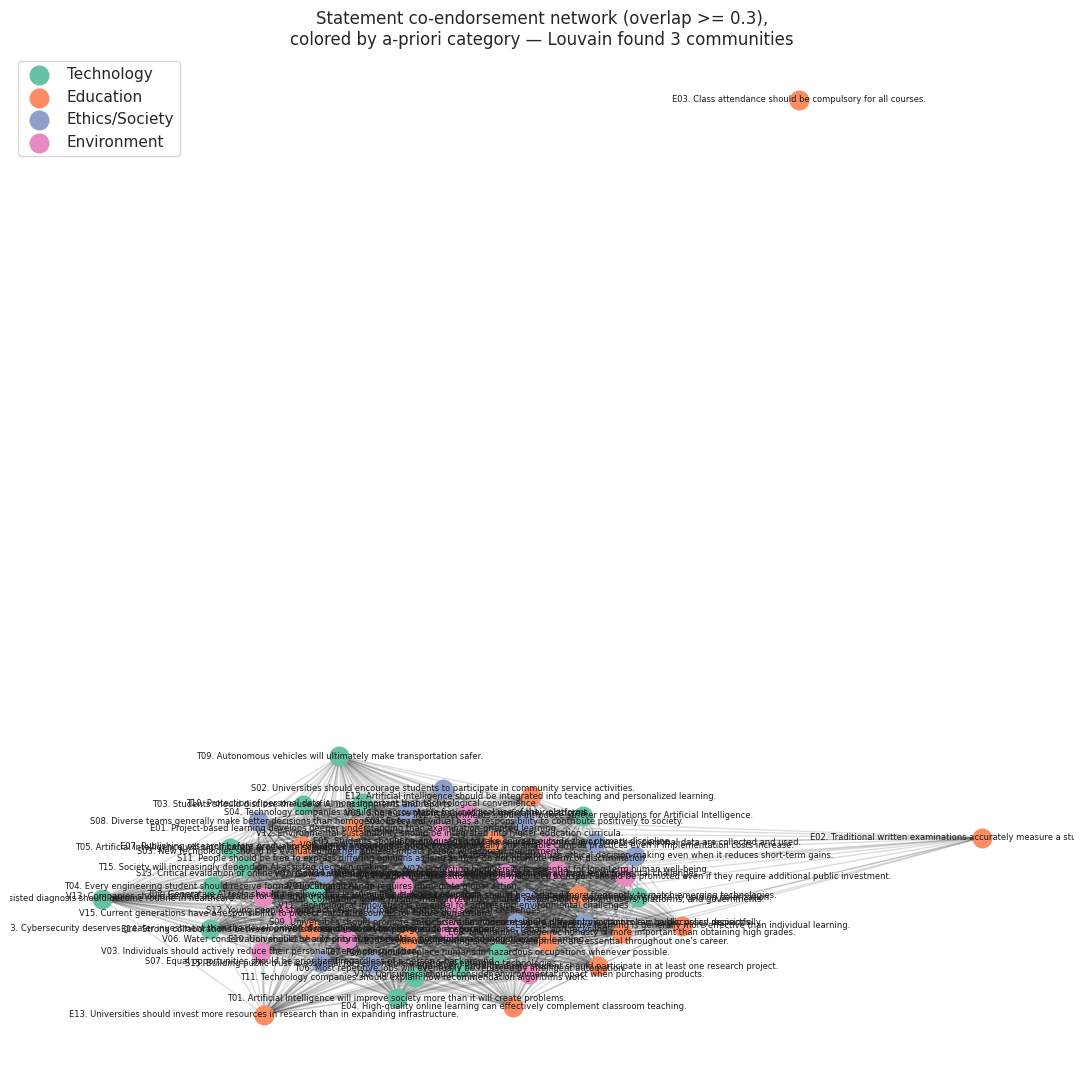

In [6]:
palette = sns.color_palette("Set2", len(category_names))
cat_color = {cat: palette[i] for i, cat in enumerate(category_names)}

pos = nx.spring_layout(G_stmt_thr, weight="weight", seed=0, k=0.4)
fig, ax = plt.subplots(figsize=(11, 11))
nx.draw_networkx_edges(G_stmt_thr, pos, alpha=0.15, ax=ax)
for cat, name in category_names.items():
    nodes = [n for n in G_stmt_thr.nodes if category_map[n] == cat]
    nx.draw_networkx_nodes(G_stmt_thr, pos, nodelist=nodes, node_color=[cat_color[cat]],
                            node_size=180, label=name, ax=ax)
nx.draw_networkx_labels(G_stmt_thr, pos, font_size=6, ax=ax)
ax.set_title(f"Statement co-endorsement network (overlap >= {STMT_PROJ_THRESHOLD}),\n"
             f"colored by a-priori category — Louvain found {len(stmt_communities)} communities")
ax.legend(scatterpoints=1)
ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Projection B — respondent-respondent (co-agreement) network

Same idea, projected onto the respondent side: two respondents are connected in
proportion to the *overlap* of statements they both agree with. This captures shared
agreement patterns, which is a different notion of "similarity" than the Pearson
correlation used in `Respondent_Similarity_Network.ipynb` (that one also credits two
respondents who *disagree* together, not just those who agree together).

In [7]:
G_resp_proj = bipartite.overlap_weighted_projected_graph(B, resp_nodes)

RESP_PROJ_THRESHOLD = 0.3
G_resp_proj_thr = nx.Graph()
G_resp_proj_thr.add_nodes_from(G_resp_proj.nodes)
G_resp_proj_thr.add_edges_from((u, v, d) for u, v, d in G_resp_proj.edges(data=True) if d["weight"] >= RESP_PROJ_THRESHOLD)

n, m = G_resp_proj_thr.number_of_nodes(), G_resp_proj_thr.number_of_edges()
print(f"Respondent co-agreement network: {n} nodes, {m} edges (overlap >= {RESP_PROJ_THRESHOLD})")
print(f"Density: {nx.density(G_resp_proj_thr):.3f}")

components = sorted(nx.connected_components(G_resp_proj_thr), key=len, reverse=True)
print(f"Connected components: {len(components)}, largest has {len(components[0])} nodes")

Respondent co-agreement network: 96 nodes, 3717 edges (overlap >= 0.3)
Density: 0.815
Connected components: 6, largest has 91 nodes


In [8]:
proj_communities = louvain_communities(G_resp_proj_thr, weight="weight", seed=0)
proj_community_of = {n: i for i, comm in enumerate(proj_communities) for n in comm}
print(f"Detected {len(proj_communities)} communities (sizes: {sorted((len(c) for c in proj_communities), reverse=True)})")

proj_degree = pd.Series(dict(G_resp_proj_thr.degree()), name="degree")
centrality = pd.DataFrame({
    "degree": nx.degree_centrality(G_resp_proj_thr.subgraph(components[0])),
    "eigenvector": nx.eigenvector_centrality(G_resp_proj_thr.subgraph(components[0]), weight="weight", max_iter=1000),
})
print("\nMost central respondents in the co-agreement network (giant component):")
centrality.sort_values("eigenvector", ascending=False).head(5)

Detected 8 communities (sizes: [50, 37, 4, 1, 1, 1, 1, 1])

Most central respondents in the co-agreement network (giant component):


,degree,eigenvector
67,0.955556,0.122785
53,0.955556,0.120634
81,0.955556,0.120565
114,0.955556,0.120538
83,0.955556,0.120188


### 4.1 Agreement-based vs. correlation-based respondent communities

If `Respondent_Similarity_Network.ipynb` has already been run, `resp_community_of`
from that notebook gives the correlation-based community assignment. Recomputing it
here (same Louvain call on the correlation network) lets us check whether "agreeing
together" and "answering similarly overall" produce the same opinion camps, via
Adjusted Rand Index — 1.0 means the two network-construction choices agree, 0 means
they're unrelated.

In [9]:
corr_sim = df_num.T.corr()
G_corr = nx.Graph()
G_corr.add_nodes_from(df_num.index)
for i, a in enumerate(df_num.index):
    for b in df_num.index[i + 1:]:
        r = corr_sim.loc[a, b]
        if pd.notna(r) and r >= 0.4:
            G_corr.add_edge(a, b, weight=r)
corr_communities = louvain_communities(G_corr, weight="weight", seed=0)
corr_community_of = {n: i for i, comm in enumerate(corr_communities) for n in comm}

common_nodes = sorted(set(proj_community_of) & set(corr_community_of))
ari = adjusted_rand_score([proj_community_of[n] for n in common_nodes],
                           [corr_community_of[n] for n in common_nodes])
print(f"Respondents present in both networks: {len(common_nodes)}")
print(f"Adjusted Rand Index (co-agreement communities vs. correlation communities): {ari:.3f}")

Respondents present in both networks: 96
Adjusted Rand Index (co-agreement communities vs. correlation communities): 0.151


## 5. Bridge statements in the co-endorsement network

Which statements connect otherwise-separate topic communities, vs. which sit purely
inside one community? Two standard measures:

- **Betweenness centrality** — how often a statement lies on the shortest path
  between other statement pairs (network-wide bridging role);
- **Participation coefficient** (Guimera-Amaral) — the fraction of a statement's edge
  weight that goes to *other* communities rather than its own (0 = all neighbors in
  the same community, close to 1 = neighbors spread evenly across communities). This
  is the standard way to separate "hub within a topic" from "bridge between topics.

In [10]:
def participation_coefficient(G, community_of):
    P = {}
    for node in G.nodes:
        neighbors = list(G.neighbors(node))
        total_w = sum(G[node][nb]["weight"] for nb in neighbors)
        if total_w == 0:
            P[node] = 0.0
            continue
        by_comm = {}
        for nb in neighbors:
            c = community_of[nb]
            by_comm[c] = by_comm.get(c, 0.0) + G[node][nb]["weight"]
        P[node] = 1 - sum((w / total_w) ** 2 for w in by_comm.values())
    return pd.Series(P, name="participation_coefficient")

bridge_stats = pd.DataFrame({
    "betweenness": nx.betweenness_centrality(G_stmt_thr, weight="weight"),
    "participation": participation_coefficient(G_stmt_thr, stmt_community_of),
})
bridge_stats["own_category"] = bridge_stats.index.map(category_map).map(category_names)
bridge_stats["detected_community"] = bridge_stats.index.map(stmt_community_of)

print("Top 8 bridge statements by betweenness centrality:")
display(bridge_stats.sort_values("betweenness", ascending=False).head(8))

print("\nTop 8 bridge statements by participation coefficient:")
display(bridge_stats.sort_values("participation", ascending=False).head(8))

Top 8 bridge statements by betweenness centrality:


,betweenness,participation,own_category,detected_community
T08. AI-assisted diagnosis should become routine in healthcare.,0.357101,0.356255,Technology,1
E13. Universities should invest more resources in research than in expanding infrastructure.,0.177089,0.346515,Education,1
E02. Traditional written examinations accurately measure a student's knowledge.,0.048510,0.127648,Education,0
T09. Autonomous vehicles will ultimately make transportation safer.,0.023963,0.320138,Technology,1
T01. Artificial Intelligence will improve society more than it will create problems.,0.018118,0.302925,Technology,0
S08. Diverse teams generally make better decisions than homogeneous teams.,0.004091,0.311063,Ethics/Society,1
V12. Environmental sustainability should be integrated into higher education curricula.,0.001169,0.304223,Environment,0
T13. Cybersecurity deserves greater investment than the development of new digital technologies.,0.000584,0.317083,Technology,1



Top 8 bridge statements by participation coefficient:


,betweenness,participation,own_category,detected_community
T08. AI-assisted diagnosis should become routine in healthcare.,0.357101,0.356255,Technology,1
E13. Universities should invest more resources in research than in expanding infrastructure.,0.177089,0.346515,Education,1
T09. Autonomous vehicles will ultimately make transportation safer.,0.023963,0.320138,Technology,1
T13. Cybersecurity deserves greater investment than the development of new digital technologies.,0.000584,0.317083,Technology,1
S03. New technologies should be evaluated for their societal impact before widespread deployment.,0.000000,0.315991,Ethics/Society,0
S04. Technology companies should be accountable for unethical use of their platforms.,0.000000,0.314538,Ethics/Society,0
T05. Artificial Intelligence will significantly accelerate scientific discovery.,0.000000,0.313166,Technology,0
E05. Students should be encouraged to take courses outside their primary discipline.,0.000000,0.312720,Education,0


Statements high on *both* measures are the clearest bridges — they sit between
detected communities network-wide (betweenness) and their immediate neighbors are
genuinely split across communities (participation), rather than one measure picking up
a low-degree statement with one lucky shortest path.

In [11]:
both_high = bridge_stats.copy()
both_high["betweenness_rank"] = both_high["betweenness"].rank(ascending=False)
both_high["participation_rank"] = both_high["participation"].rank(ascending=False)
both_high["combined_rank"] = both_high["betweenness_rank"] + both_high["participation_rank"]
both_high.sort_values("combined_rank").head(8)[["own_category", "detected_community", "betweenness", "participation"]]

,own_category,detected_community,betweenness,participation
T08. AI-assisted diagnosis should become routine in healthcare.,Technology,1,0.357101,0.356255
E13. Universities should invest more resources in research than in expanding infrastructure.,Education,1,0.177089,0.346515
T09. Autonomous vehicles will ultimately make transportation safer.,Technology,1,0.023963,0.320138
T13. Cybersecurity deserves greater investment than the development of new digital technologies.,Technology,1,0.000584,0.317083
S08. Diverse teams generally make better decisions than homogeneous teams.,Ethics/Society,1,0.004091,0.311063
V03. Individuals should actively reduce their personal energy consumption.,Environment,0,0.000584,0.312596
V12. Environmental sustainability should be integrated into higher education curricula.,Environment,0,0.001169,0.304223
S03. New technologies should be evaluated for their societal impact before widespread deployment.,Ethics/Society,0,0.000000,0.315991


## Summary

- Built a bipartite respondent-statement graph from binarized agreement (score >= 1)
  and reported its density and the degree distribution on both sides (Section 2) —
  which statements/respondents are the most "agreeable" hubs.
- **Projection A** (statement-statement co-endorsement, Section 3): Louvain communities
  compared against the a-priori T/E/S/V labels via Adjusted Rand Index, complementing
  the correlation-based item network in `EDA.ipynb` Section 11 with an
  agreement-overlap-based alternative.
- **Projection B** (respondent-respondent co-agreement, Section 4): density, components,
  centrality and communities, then cross-checked against the correlation-based
  respondent network from `Respondent_Similarity_Network.ipynb` via Adjusted Rand Index
  (Section 4.1) — a direct comparison of the two network-construction philosophies
  (shared agreement vs. overall answer-pattern correlation).

- **Bridge statements (Section 5):** betweenness centrality and participation
  coefficient on the statement co-endorsement network identify which statements link
  otherwise-separate detected communities, vs. which are purely within-community hubs —
  a concrete, per-statement view of where the survey's a-priori T/E/S/V structure
  breaks down (consistent with the low ARI found in Section 3).